[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/10zva0mhu-Gm7xtX7WhpeOMU0xvE8wKSD?usp=sharing)

In [ ]:
!pip install pandas numpy scikit-learn imbalanced-learn xgboost seaborn matplotlib

# Credit Card Fraud Detection using Machine Learning

This notebook implements Random Forest and XGBoost models for detecting fraudulent transactions in an imbalanced dataset.

Evaluation metrics: Precision, Recall, F1-score, AUPRC.

In [ ]:


# =========================================================
# SECTION 1: IMPORT LIBRARIES
# =========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, auc

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Handling imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
# =========================================================
# SECTION 2: LOAD DATA
# =========================================================

# Loads dataset
import os

if os.path.exists("creditcard.csv"):
    df = pd.read_csv("creditcard.csv")
else:
    print("Please upload creditcard.csv")

# Basic overview
print("Dataset shape:", df.shape)
print("\nClass distribution:\n", df['Class'].value_counts())

Dataset shape: (284807, 31)

Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


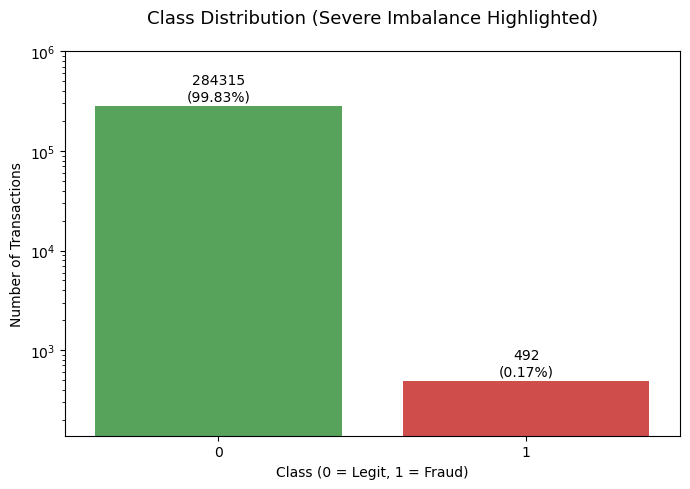

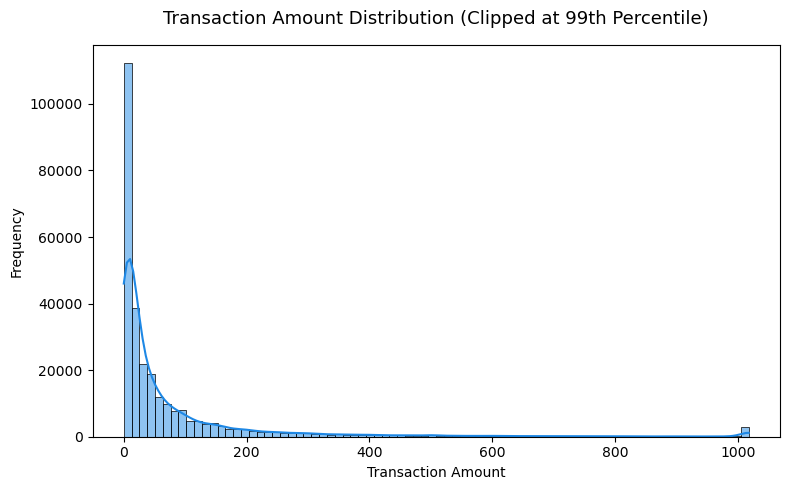

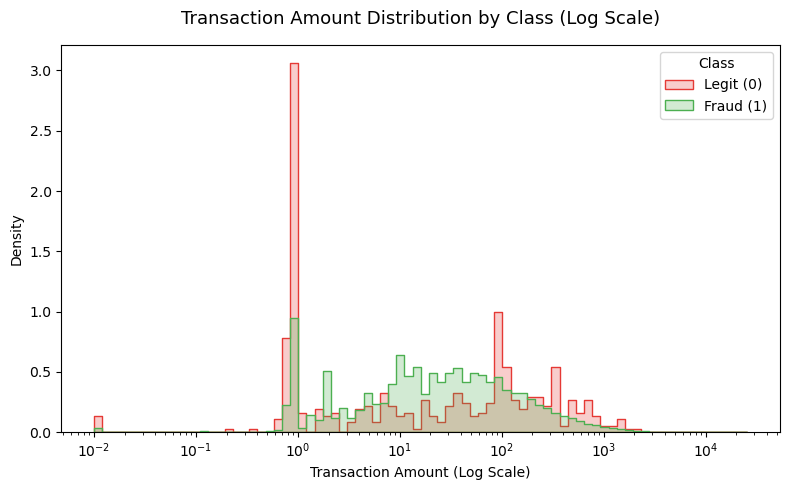

In [ ]:
# =========================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
# =========================================================

# ---------------------------------------------------------
# 1. CHECK MISSING VALUES
# ---------------------------------------------------------
print("Missing values:\n", df.isnull().sum())


# ---------------------------------------------------------
# 2. CLASS DISTRIBUTION
# ---------------------------------------------------------
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='Class',
    data=df,
    palette=['#4CAF50', '#E53935']
)

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    y = p.get_height()
    offset = y * 0.05

    ax.annotate(f'{count}\n({percentage:.2f}%)',
                (p.get_x() + p.get_width() / 2., y + offset),
                ha='center', va='bottom', fontsize=10)

# Add spacing between title and plot
plt.title("Class Distribution (Severe Imbalance Highlighted)", fontsize=13, pad=20)

plt.xlabel("Class (0 = Legit, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.yscale('log')

# Margin control
ax.margins(y=0.2)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. TRANSACTION AMOUNT DISTRIBUTION
# ---------------------------------------------------------
plt.figure(figsize=(8,5))

# This is to clip extreme outliers for better visibility

amount_clip = df['Amount'].clip(upper=df['Amount'].quantile(0.99))

sns.histplot(

    amount_clip,

    bins=80,

    kde=True,

    color='#1E88E5'

)

plt.title("Transaction Amount Distribution (Clipped at 99th Percentile)", fontsize=13, pad=15)

plt.xlabel("Transaction Amount")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()
# ---------------------------------------------------------
# 4. TRANSACTION AMOUNT BY CLASS
# ---------------------------------------------------------
plt.figure(figsize=(8,5))

sns.histplot(

    data=df,

    x='Amount',

    hue='Class',

    bins=80,

    log_scale=True,

    palette=['#4CAF50', '#E53935'],

    element='step',

    stat='density',

    common_norm=False

)

plt.title("Transaction Amount Distribution by Class (Log Scale)", fontsize=13, pad=15)

plt.xlabel("Transaction Amount (Log Scale)")

plt.ylabel("Density")

plt.legend(title="Class", labels=["Legit (0)", "Fraud (1)"])

plt.tight_layout()

plt.show()

In [ ]:
# =========================================================
# SECTION 4: DATA PREPROCESSING
# =========================================================

# So as to separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split thi s is stratified due to imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (227845, 30)
Test set: (56962, 30)


In [ ]:
# =========================================================
# SECTION 5: DEFINING MODEL PIPELINES
# =========================================================

rf_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),        # For handling imbalance in Random Forest pipeline
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

xgb_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),        # Also to Handle imbalance in XGBoost pipeline
    ('xgb', XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
# =========================================================
# SECTION 6: HYPERPARAMETER SEARCH SPACE
# =========================================================

# Random Forest parameters
rf_param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

# XGBoost parameters
xgb_param_grid = {
    'xgb__n_estimators': [50, 100, 200],
    'xgb__max_depth': [3, 6, 10],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

In [ ]:
# =========================================================
# SECTION 7: HYPERPARAMETER OPTIMIZATION
# =========================================================

from sklearn.model_selection import RandomizedSearchCV

# Random Forest optimization
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=5,                 # Number of parameter combinations
    scoring='f1',              # Important for imbalance
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# XGBoost optimization
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=5,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# =========================================================
# SECTION 8: HYPERPARAMETER TUNING WITH TIMING
# =========================================================

import time

# -------------------------
# RANDOM FOREST TIMING
# -------------------------
start_rf = time.time()

rf_search.fit(X_train, y_train)

end_rf = time.time()
rf_time = end_rf - start_rf

print("Best RF Params:", rf_search.best_params_)
print(f"Random Forest Training Time: {rf_time:.2f} seconds")


# -------------------------
# XGBOOST TIMING
# -------------------------
start_xgb = time.time()

xgb_search.fit(X_train, y_train)

end_xgb = time.time()
xgb_time = end_xgb - start_xgb

print("Best XGB Params:", xgb_search.best_params_)
print(f"XGBoost Training Time: {xgb_time:.2f} seconds")

# -------------------------
# EXTRACT BEST MODELS
# -------------------------
best_rf = rf_search.best_estimator_

best_xgb = xgb_search.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best RF Params: {'rf__n_estimators': 200, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_depth': 20}
Random Forest Training Time: 1074.00 seconds
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best XGB Params: {'xgb__subsample': 1.0, 'xgb__n_estimators': 200, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 1.0}
XGBoost Training Time: 25.99 seconds


In [ ]:
# =========================================================
# SECTION 9: MODEL PREDICTIONS
# =========================================================

y_pred_rf = best_rf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

In [ ]:
# =========================================================
# SECTION 10: MODEL EVALUATION
# =========================================================

print("=== RANDOM FOREST (OPTIMIZED) ===")
print(classification_report(y_test, y_pred_rf))

print("=== XGBOOST (OPTIMIZED) ===")
print(classification_report(y_test, y_pred_xgb))

=== RANDOM FOREST (OPTIMIZED) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.83      0.79        98

    accuracy                           1.00     56962
   macro avg       0.87      0.91      0.89     56962
weighted avg       1.00      1.00      1.00     56962

=== XGBOOST (OPTIMIZED) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.58      0.85      0.69        98

    accuracy                           1.00     56962
   macro avg       0.79      0.92      0.84     56962
weighted avg       1.00      1.00      1.00     56962



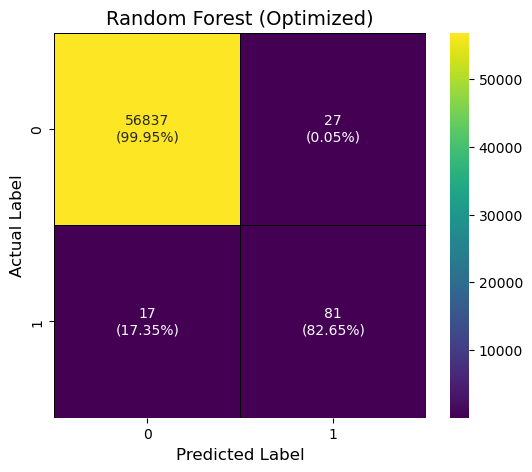

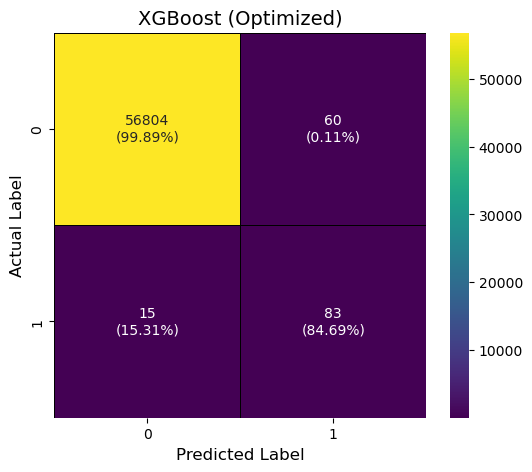

In [ ]:
# =========================================================
# SECTION 11: CONFUSION MATRIX
# =========================================================

import numpy as np

def plot_conf_matrix(y_true, y_pred, title):
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Normalize for percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Create annotation labels (count + percentage)
    labels = np.array([
        [f"{cm[i, j]}\n({cm_normalized[i, j]*100:.2f}%)"
         for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])

    # Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=labels,
        fmt='',
        cmap='viridis',
        cbar=True,
        linewidths=0.5,
        linecolor='black'
    )

    plt.title(title, fontsize=14)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("Actual Label", fontsize=12)

    plt.show()


# Plot for both models
plot_conf_matrix(y_test, y_pred_rf, "Random Forest (Optimized)")
plot_conf_matrix(y_test, y_pred_xgb, "XGBoost (Optimized)")

In [ ]:
# =========================================================
# SECTION 12: FINAL MODEL EVALUATION
# =========================================================

def evaluate_model(name, y_true, y_probs, y_pred):
    precision, recall, _ = precision_recall_curve(y_true, y_probs)

    return {
        "Model": name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "AUPRC": auc(recall, precision)
    }

# Get probabilities
y_probs_rf = best_rf.predict_proba(X_test)[:, 1]
y_probs_xgb = best_xgb.predict_proba(X_test)[:, 1]

results = [
    evaluate_model("Random Forest (Optimized)", y_test, y_probs_rf, y_pred_rf),
    evaluate_model("XGBoost (Optimized)", y_test, y_probs_xgb, y_pred_xgb)
]

results_df = pd.DataFrame(results)
print(results_df)

                       Model  Precision    Recall  F1 Score     AUPRC
0  Random Forest (Optimized)    0.75000  0.826531  0.786408  0.860532
1        XGBoost (Optimized)    0.58042  0.846939  0.688797  0.854919


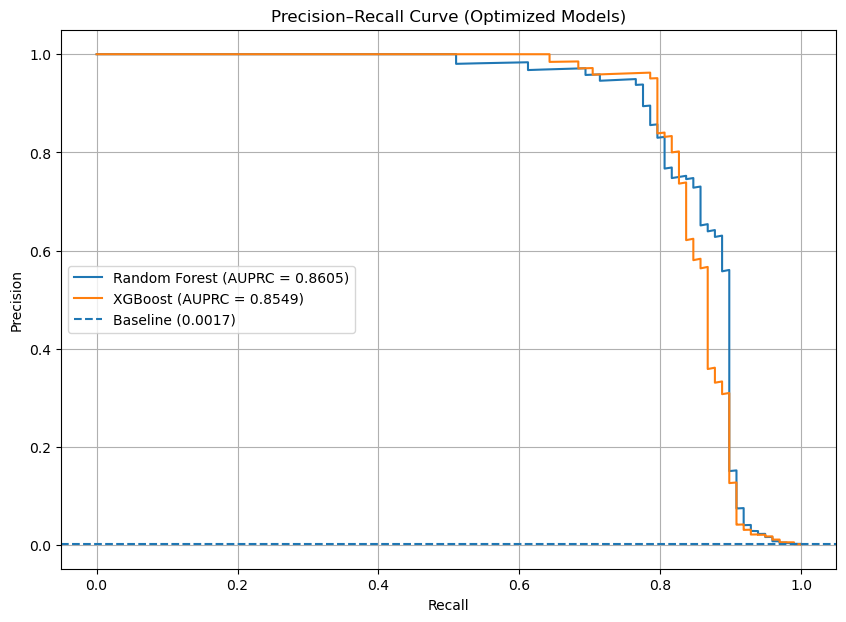

In [ ]:
# =========================================================
# SECTION 13: PRECISION-RECALL CURVE
# =========================================================

plt.figure(figsize=(10, 7))

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_probs_rf)
plt.plot(recall_rf, precision_rf,
         label=f'Random Forest (AUPRC = {auc(recall_rf, precision_rf):.4f})')

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_probs_xgb)
plt.plot(recall_xgb, precision_xgb,
         label=f'XGBoost (AUPRC = {auc(recall_xgb, precision_xgb):.4f})')

# Baseline
baseline = sum(y_test) / len(y_test)
plt.axhline(y=baseline, linestyle='--', label=f'Baseline ({baseline:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (Optimized Models)')
plt.legend()
plt.grid(True)

plt.show()